In [60]:
import osmnx as ox
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.ticker import PercentFormatter, FuncFormatter
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd



In [61]:
# -------------------------------
# Step 1: Load the road network
# -------------------------------
location = "Malta (island)"
#location = "Southern Region, Malta"
G = ox.graph.graph_from_place(location, network_type="bike", simplify=True)

# -------------------------------
# Step 2: Set OpenTopodata EU-DEM API
# -------------------------------
# Source: https://www.opentopodata.org/
ox.settings.elevation_url_template = (
    "https://api.opentopodata.org/v1/eudem25m?locations={locations}"
)

# -------------------------------
# Step 3: Add node elevations
# -------------------------------
G = ox.add_node_elevations_google(G, batch_size=100, pause=5)

# -------------------------------
# Step 4: Add edge grade (slope)
# -------------------------------
G = ox.elevation.add_edge_grades(G, add_absolute=True)

In [62]:
def my_plot(G):
    # Set the color map
    cmap = plt.cm.coolwarm

    # Clamp values between -2 and 2, but include outliers by clipping
    norm = mcolors.Normalize(vmin=-.1, vmax=.1, clip=False)


    # -------------------------------
    # Step 5: Verify elevation distribution
    # -------------------------------
    elevations = [
        data.get("elevation")
        for _, data in G.nodes(data=True)
        if data.get("elevation") is not None
    ]
    print(f"Fetched elevations for {len(elevations)} / {G.number_of_nodes()} nodes")
    plt.hist(elevations, bins=40, color='purple')
    plt.title("Node Elevation Distribution")
    plt.xlabel("Elevation (m)")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.show()

    # -------------------------------
    # Step 6: Visualize edge slopes
    # -------------------------------
    #NOTE removed abs
    grade_abs_values = [
        data.get("grade", 0)
        for u, v, k, data in G.edges(keys=True, data=True)
        if data.get("grade") is not None
    ]

    fig, (ax1, ax2,) = plt.subplots(1, 2, figsize=(15, 5))

    # log scale
    n,bins, patches = ax1.hist(grade_abs_values, bins=16, color='green', alpha=0.7,  edgecolor='black')
    ax1.set_title("Grade frequency (log scale)")
    ax1.set_xlabel("Grade (%)")
    ax1.set_ylabel("Frequency")
    ax1.set_yscale("log")
    ax1.grid(axis = 'y')
    ax1.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))  # 0.1 -> 10%


    for bin_left, bin_right, patch in zip(bins[:-1], bins[1:], patches):
        bin_center = 0.5 * (bin_left + bin_right)
        color = cmap(norm(bin_center))
        patch.set_facecolor(color)



    #typical grades
    steep_grades = [g for g in grade_abs_values if g < 0.2 and g>-0.2]
    n,bins, patches = ax2.hist(steep_grades, bins=40, alpha=0.7, edgecolor='black')
    ax2.set_title("Distribution of Typical Road Grades")
    ax2.set_xlabel("Grade (%)")
    ax2.set_ylabel("Frequency")
    ax2.set_xticks(bins, minor=True)
    ax2.grid(axis = 'y')
    ax2.tick_params(axis='x', which='minor', bottom=False, labelbottom=False)
    ax2.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))

    for bin_left, bin_right, patch in zip(bins[:-1], bins[1:], patches):
        bin_center = 0.5 * (bin_left + bin_right)
        color = cmap(norm(bin_center))
        patch.set_facecolor(color)

    plt.tight_layout()
    plt.show()

    print(f"Avg grade: {np.mean(grade_abs_values):.3f}")
    print(f"Max grade: {np.max(grade_abs_values):.2f}")
    print(f"Edges with grade > 50%: {sum(g > 0.5 for g in grade_abs_values)}")


    """   
     sm = plt.cm.ScalarMappable(
        cmap="plasma",
        norm=plt.Normalize(
            vmin=min(d["grade_abs"] for _, _, _, d in G.edges(keys=True, data=True) if d.get("grade_abs") is not None),
            vmax=max(d["grade_abs"] for _, _, _, d in G.edges(keys=True, data=True) if d.get("grade_abs") is not None)
        )
    )"""

    # Get edge colors using the full grade (not grade_abs)
    edge_colors = [
        cmap(norm(data.get("grade", 0)))
        for _, _, _, data in G.edges(keys=True, data=True)
    ]


    # Plot with fixed color scale
    fig, ax = ox.plot.plot_graph(
        G,
        edge_color=edge_colors,
        edge_linewidth=0.5,
        node_size=0,
        bgcolor="k",
        show=False,
        close=False
    )

    # Create colorbar with fixed scale
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.01, extend='both',
                        format=PercentFormatter(xmax=1.0, decimals=0))
    cbar.set_label("Edge Grade (%)")
    cbar.update_ticks()
    plt.show()


In [63]:
def my_data(G):
    nan_nodes = [
        node for node, data in G.nodes(data=True)
        if data.get("elevation") is None or np.isnan(data.get("elevation"))
    ]
    print(f"Nodes with missing/NaN elevation: {len(nan_nodes)}")


    bad_lengths = [
        (u, v) for u, v, k, data in G.edges(keys=True, data=True)
        if data.get("length") in [None, 0]
    ]
    print(f"Edges with invalid length: {len(bad_lengths)}")


    for u, v, k, data in list(G.edges(keys=True, data=True))[:5]:
        elev_u = G.nodes[u].get("elevation")
        elev_v = G.nodes[v].get("elevation")
        length = data.get("length")
        print(f"{u}->{v}: elev_u={elev_u}, elev_v={elev_v}, length={length}")
        if elev_u is not None and elev_v is not None and length:
            slope = (elev_v - elev_u) / length
            print(f"→ grade: {slope:.4f}")



Nodes with missing/NaN elevation: 499
Edges with invalid length: 0
197859->2879267467: elev_u=29.257383346557617, elev_v=28.78795623779297, length=32.101474698698986
→ grade: -0.0146
197859->2717946858: elev_u=29.257383346557617, elev_v=47.69524002075195, length=452.35030719160335
→ grade: 0.0408
197869->5044930083: elev_u=2.5609381198883057, elev_v=1.8100600242614746, length=15.697675611299502
→ grade: -0.0478
197874->3455878004: elev_u=114.95625305175781, elev_v=119.49034118652344, length=108.00437475842378
→ grade: 0.0420
197874->148302046: elev_u=114.95625305175781, elev_v=112.20821380615234, length=88.1936123733482
→ grade: -0.0312
Fetched elevations for 34609 / 34609 nodes


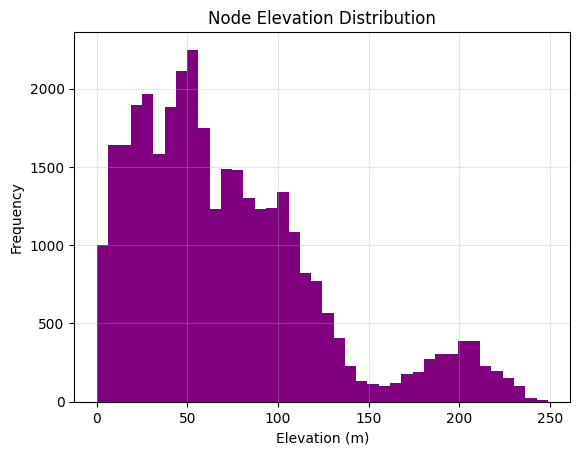

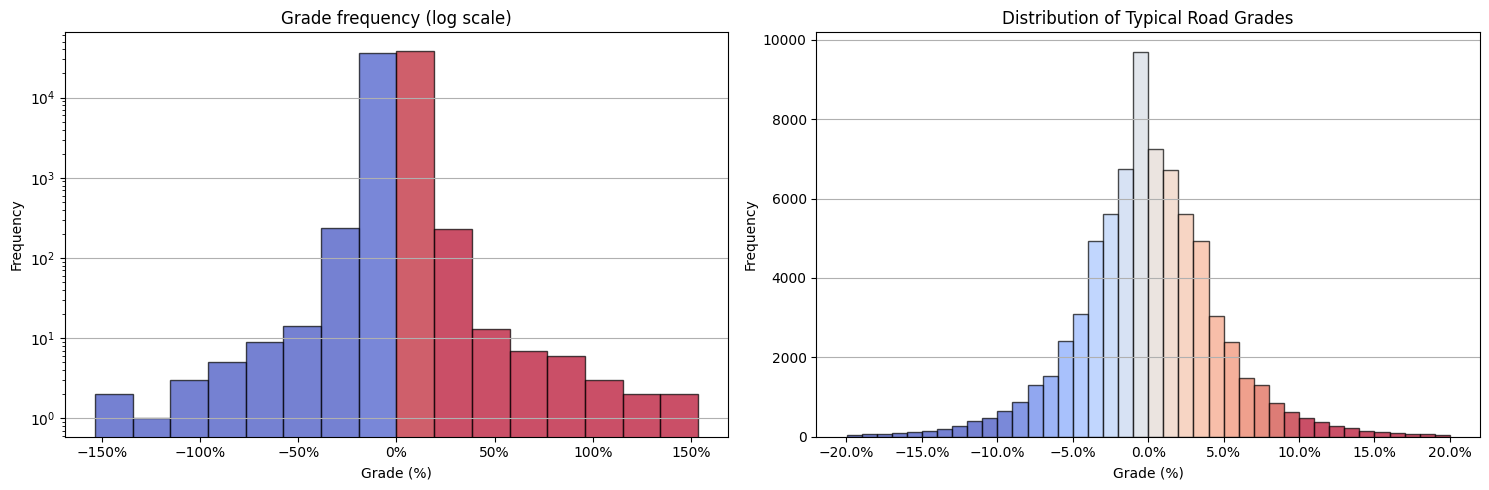

Avg grade: nan
Max grade: nan
Edges with grade > 50%: 24


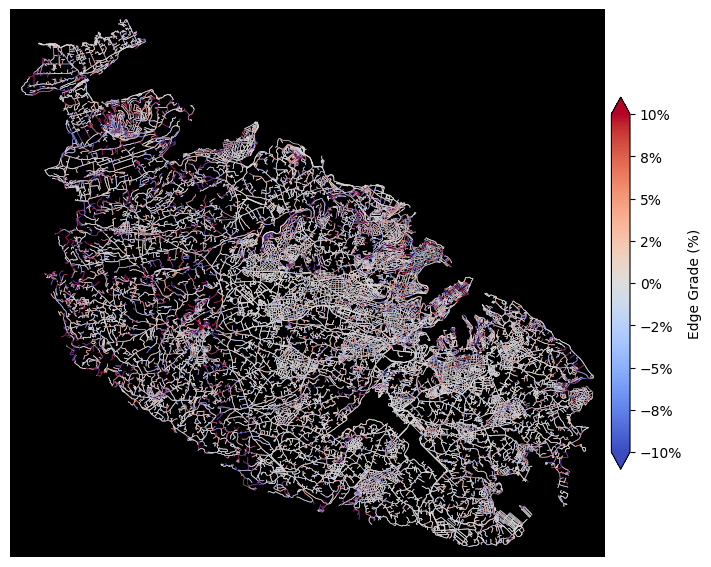

In [64]:
my_data(G)
my_plot(G)

In [65]:
import numpy as np
import copy


G_clean = copy.deepcopy(G)


# Step 1: Extract valid elevation values
valid_elevations = [
    data["elevation"]
    for _, data in G_clean.nodes(data=True)
    if data.get("elevation") is not None and not np.isnan(data["elevation"])
]

# Step 2: Compute median
median_elevation = np.median(valid_elevations)
print(f"Using median elevation = {median_elevation:.2f} m")

# Step 3: Replace NaN/missing elevations with the median
max_iter = 10
for it in range(max_iter):
    changed = 0
    for node, data in G_clean.nodes(data=True):
        elev = data.get("elevation")
        if elev is None or np.isnan(elev):
            neigh_elevs = [
                G_clean.nodes[n].get("elevation")
                for n in G.neighbors(node)
                if G_clean.nodes[n].get("elevation") is not None
                and not np.isnan(G_clean.nodes[n]["elevation"])
            ]
            if neigh_elevs:
                data["elevation"] = np.median(neigh_elevs)
                changed += 1
   
    print(f"Iteration {it+1}: imputed {changed} nodes")
    if changed == 0:
        break


Using median elevation = 59.37 m
Iteration 1: imputed 351 nodes
Iteration 2: imputed 114 nodes
Iteration 3: imputed 29 nodes
Iteration 4: imputed 2 nodes
Iteration 5: imputed 0 nodes


Nodes with missing/NaN elevation: 3
Edges with invalid length: 0
197859->2879267467: elev_u=29.257383346557617, elev_v=28.78795623779297, length=32.101474698698986
→ grade: -0.0146
197859->2717946858: elev_u=29.257383346557617, elev_v=47.69524002075195, length=452.35030719160335
→ grade: 0.0408
197869->5044930083: elev_u=2.5609381198883057, elev_v=1.8100600242614746, length=15.697675611299502
→ grade: -0.0478
197874->3455878004: elev_u=114.95625305175781, elev_v=119.49034118652344, length=108.00437475842378
→ grade: 0.0420
197874->148302046: elev_u=114.95625305175781, elev_v=112.20821380615234, length=88.1936123733482
→ grade: -0.0312
Fetched elevations for 34609 / 34609 nodes


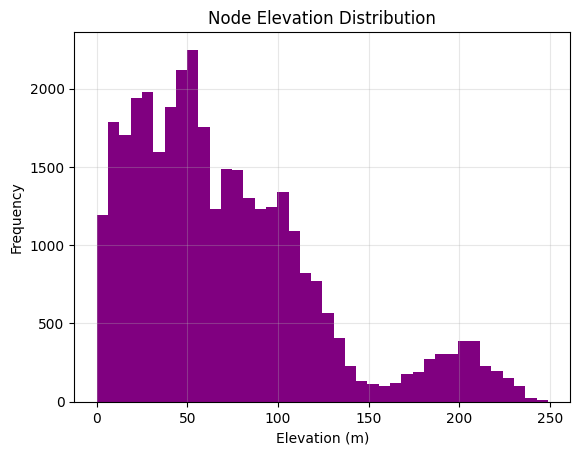

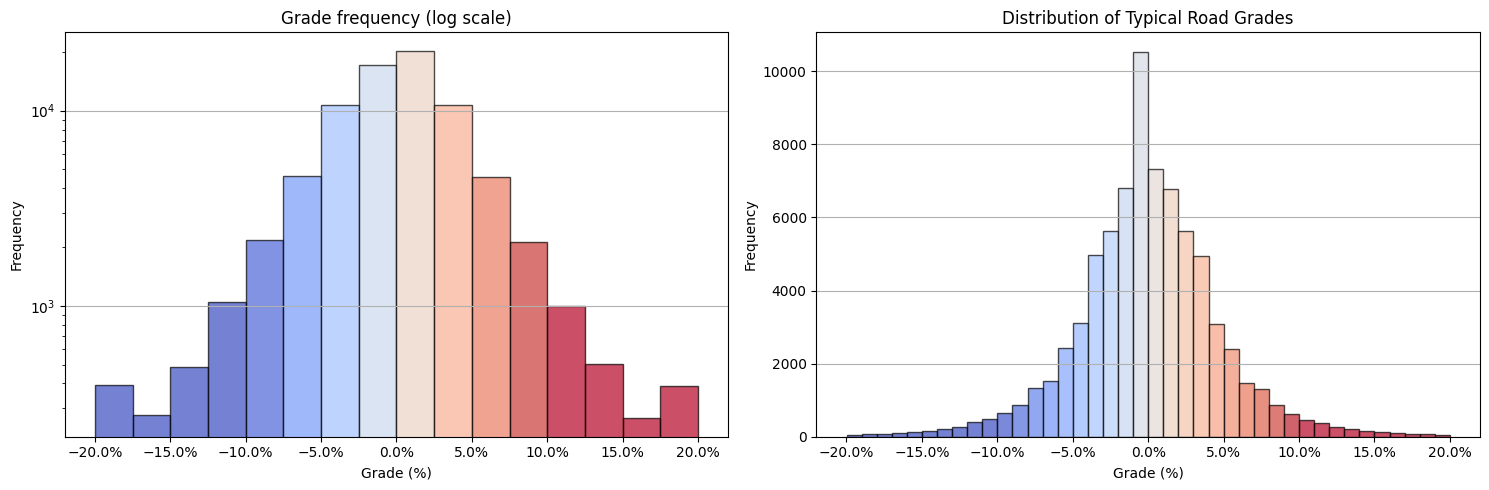

Avg grade: nan
Max grade: nan
Edges with grade > 50%: 0


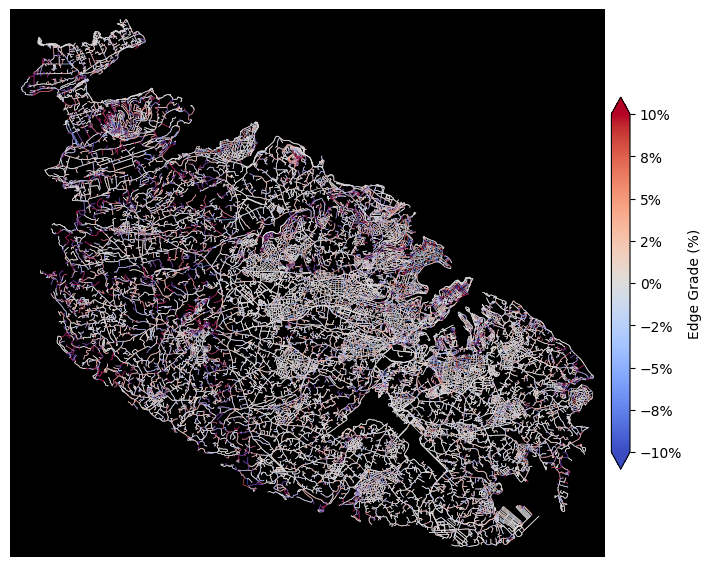

In [68]:

import math


G_clean = ox.elevation.add_edge_grades(G_clean, add_absolute=True)

for _,_, data in G_clean.edges(data=True):
    data["grade"] = float(np.clip(data["grade"], -0.2, 0.2))
    data["grade_abs"] = float(min(data["grade_abs"], 0.2))

my_data(G_clean)
my_plot(G_clean)

In [67]:
import numpy as np

# Calculate grades again (if not already)
G_clean = ox.add_edge_grades(G_clean, add_absolute=False)

# Find suspect edges
suspect_edges = [
    (u, v, data)
    for u, v, data in G_clean.edges(data=True)
    if abs(data.get("grade", 0)) > 1  # >100%
]

print(f"Found {len(suspect_edges)} suspect edges out of {len(G_clean.edges())}")


for u, v, data in suspect_edges[:10]:
    elev_u = G_clean.nodes[u]["elevation"]
    elev_v = G_clean.nodes[v]["elevation"]
    length = data["length"]
    print(f"{u}->{v}: Δh={elev_v - elev_u:.1f}m over {length:.1f}m  grade={data['grade']*100:.1f}%")


Found 16 suspect edges out of 76667
156486858->8960552002: Δh=-36.2m over 23.6m  grade=-153.6%
246587650->12695802595: Δh=1.3m over 1.3m  grade=100.4%
1529343117->265570960: Δh=-11.9m over 10.3m  grade=-115.9%
1529343279->265043153: Δh=22.3m over 19.3m  grade=115.4%
1529343279->1529343268: Δh=15.5m over 12.4m  grade=124.7%
5308477764->5308814196: Δh=-44.3m over 20.2m  grade=-219.6%
5308814196->5308477764: Δh=44.3m over 20.2m  grade=219.6%
6723345670->6723345672: Δh=20.6m over 18.8m  grade=109.6%
6723345672->6723345670: Δh=-20.6m over 18.8m  grade=-109.6%
8960552002->156486858: Δh=36.2m over 23.6m  grade=153.6%
